In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("/content/Customer_Data.csv")

In [5]:
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [6]:
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [8]:
df=df.drop(["Customer_ID"],axis=1)

In [9]:
df.shape

(6418, 31)

In [10]:
df.isnull().sum()

,0
Gender,0
Age,0
Married,0
State,0
Number_of_Referrals,0
Tenure_in_Months,0
Value_Deal,3548
Phone_Service,0
Multiple_Lines,622
Internet_Service,0


In [11]:
null_columns = df.columns[df.isnull().any()]

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6418.0,47.070739,16.703633,18.00,33.0000,46.000,60.0000,85.00
Number_of_Referrals,6418.0,7.427859,4.621519,0.00,3.0000,7.000,11.0000,15.00
Tenure_in_Months,6418.0,17.342786,10.576391,1.00,8.0000,16.000,27.0000,36.00
Monthly_Charge,6418.0,63.652867,31.188823,-10.00,30.5625,70.100,89.7500,118.75
Total_Charges,6418.0,2280.374858,2268.049985,18.80,395.7250,1396.125,3783.6000,8684.80
Total_Refunds,6418.0,1.924944,7.849083,0.00,0.0000,0.000,0.0000,49.79
Total_Extra_Data_Charges,6418.0,6.718604,24.722533,0.00,0.0000,0.000,0.0000,150.00
Total_Long_Distance_Charges,6418.0,748.703468,847.672844,0.00,70.8050,407.475,1182.9175,3564.72
Total_Revenue,6418.0,3033.871987,2866.505426,21.36,603.7425,2108.635,4801.5375,11979.34


Data quality check: Monthly_Charge has a negative minimum value


In [ ]:
# Monthly_Charge min was -10 in describe() above - investigate before trusting any charge-based insight
print("Rows with negative Monthly_Charge:", (df['Monthly_Charge'] < 0).sum())
df[df['Monthly_Charge'] < 0]


In [ ]:
# Treat negative charges as bad data - clip at 0 (adjust this logic if you find a legitimate reason, e.g. credits)
df['Monthly_Charge'] = df['Monthly_Charge'].clip(lower=0)
df['Monthly_Charge'].describe()


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
num_cols = df.select_dtypes(include='number').columns

In [15]:
for col in cat_cols:
  print(df[col].value_counts())
  print("*"*50)

Gender
Female    4048
Male      2370
Name: count, dtype: int64
**************************************************
Married
No     3223
Yes    3195
Name: count, dtype: int64
**************************************************
State
Uttar Pradesh      629
Tamil Nadu         600
Maharashtra        504
Karnataka          470
Haryana            398
Andhra Pradesh     395
West Bengal        368
Punjab             342
Bihar              336
Gujarat            335
Jammu & Kashmir    320
Madhya Pradesh     288
Telangana          281
Rajasthan          259
Kerala             200
Odisha             152
Assam              139
Delhi              127
Jharkhand          113
Uttarakhand         62
Chhattisgarh        59
Puducherry          41
Name: count, dtype: int64
**************************************************
Value_Deal
Deal 2    758
Deal 5    738
Deal 4    540
Deal 1    469
Deal 3    365
Name: count, dtype: int64
**************************************************
Phone_Service
Yes    5796
No  

dealing with null values

In [16]:
df[null_columns].head()

,Value_Deal,Multiple_Lines,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Churn_Category,Churn_Reason
0,NaN,No,Cable,No,Yes,No,Yes,Yes,No,No,Yes,NaN,NaN
1,NaN,Yes,Cable,No,No,No,No,No,Yes,Yes,No,NaN,NaN
2,Deal 5,No,Fiber Optic,No,No,Yes,No,No,No,No,Yes,Competitor,Competitor had better devices
3,Deal 4,No,Fiber Optic,No,Yes,Yes,No,Yes,Yes,No,Yes,Dissatisfaction,Product dissatisfaction
4,NaN,No,Fiber Optic,No,No,No,Yes,Yes,No,No,Yes,Dissatisfaction,Network reliability


for churn category null value,we simple its replace with No complain,because only churned customer has complain

In [17]:
df[["Churn_Category","Churn_Reason"]] = df[["Churn_Category","Churn_Reason"]].fillna("No complain")

In [ ]:
# FIX: nulls here are structural, not random - filling with mode is wrong.
# Internet-related columns are null because Internet_Service == 'No' (no internet at all).
service_cols = ['Internet_Type','Online_Security','Online_Backup','Device_Protection_Plan',
                'Premium_Support','Streaming_TV','Streaming_Movies','Streaming_Music','Unlimited_Data']
df[service_cols] = df[service_cols].fillna("No Internet Service")

# Multiple_Lines is null because Phone_Service == 'No'
df['Multiple_Lines'] = df['Multiple_Lines'].fillna("No Phone Service")

# Value_Deal is null because the customer isn't on any promotional deal
df['Value_Deal'] = df['Value_Deal'].fillna("No Deal")

# sanity check - should all be 0 now (Churn_Category/Reason already handled above)
df.isnull().sum()


In [19]:
df.duplicated().sum()

np.int64(0)

Univarite analysis

In [20]:
df["Customer_Status"].value_counts()

,count
Customer_Status,
Stayed,4275
Churned,1732
Joined,411


not so much inbalanced

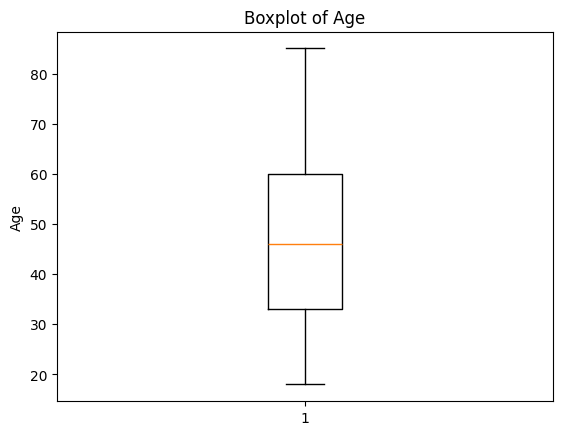

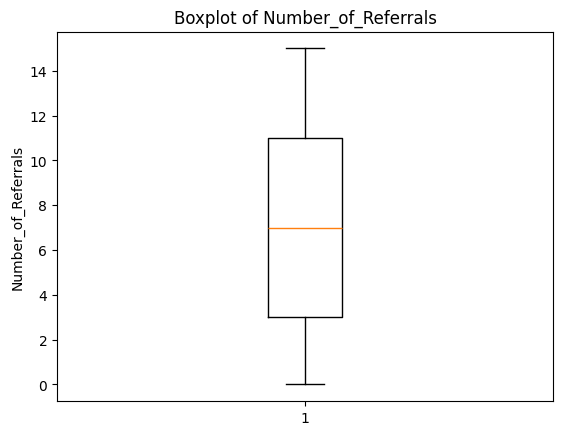

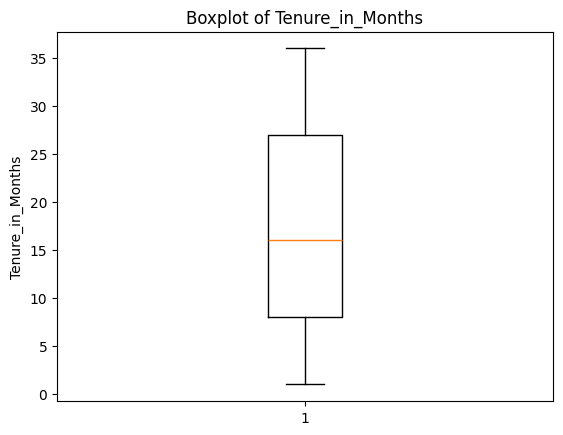

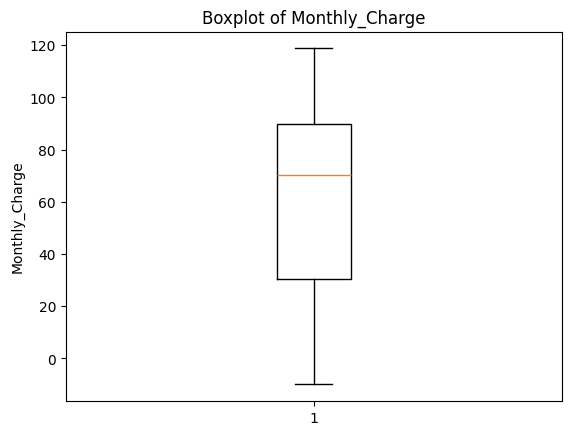

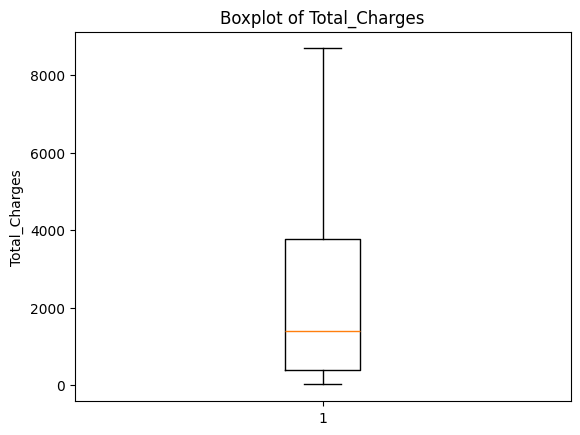

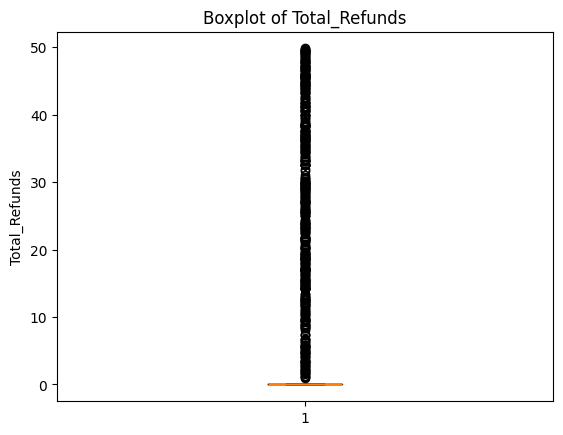

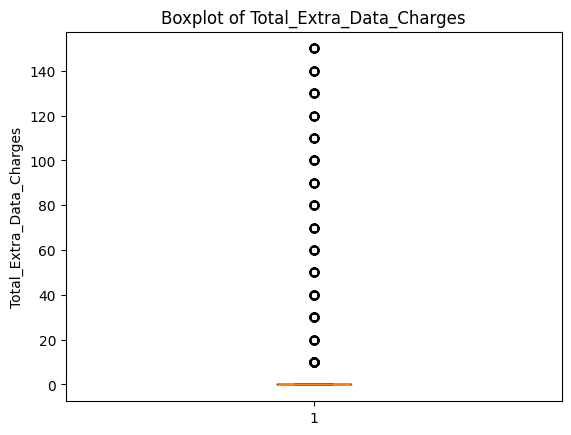

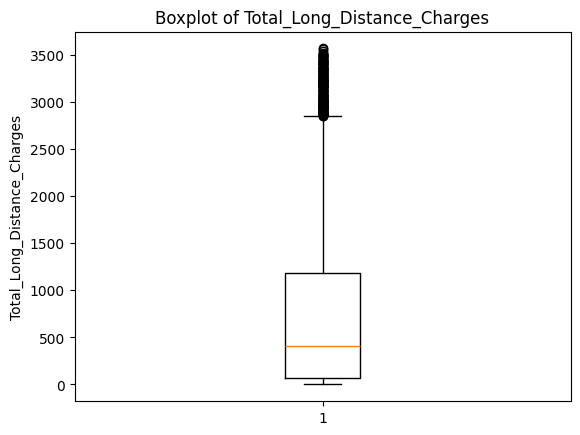

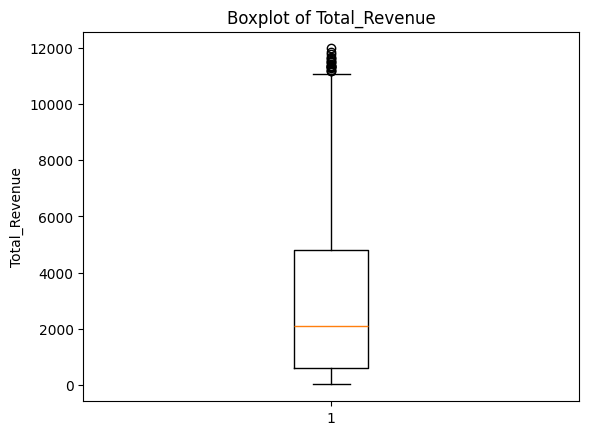

In [21]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()

Bivariate analysis


In [22]:
df[cat_cols].head()

,Gender,Married,State,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,...,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Customer_Status,Churn_Category,Churn_Reason
0,Male,No,Delhi,Deal 2,Yes,No,Yes,Cable,No,Yes,...,Yes,No,No,Yes,One Year,Yes,Credit Card,Stayed,No complain,No complain
1,Female,Yes,Maharashtra,Deal 2,Yes,Yes,Yes,Cable,No,No,...,No,Yes,Yes,No,Month-to-Month,No,Credit Card,Stayed,No complain,No complain
2,Male,No,West Bengal,Deal 5,Yes,No,Yes,Fiber Optic,No,No,...,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Competitor,Competitor had better devices
3,Male,No,Karnataka,Deal 4,Yes,No,Yes,Fiber Optic,No,Yes,...,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Churned,Dissatisfaction,Product dissatisfaction
4,Female,No,Tamil Nadu,Deal 2,Yes,No,Yes,Fiber Optic,No,No,...,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,Churned,Dissatisfaction,Network reliability


In [23]:
df[num_cols].head()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
0,35,7,27,65.6,593.30,0.00,0,381.51,974.81
1,45,14,13,-4.0,542.40,38.33,10,96.21,610.28
2,51,4,35,73.9,280.85,0.00,0,134.60,415.45
3,79,3,21,98.0,1237.85,0.00,0,361.66,1599.51
4,80,3,8,83.9,267.40,0.00,0,22.14,289.54


In [24]:
pd.crosstab(
    df['Customer_Status'],
    df['Churn_Category'],
    normalize='index'
) * 100

Churn_Category,Attitude,Competitor,Dissatisfaction,No complain,Other,Price
Customer_Status,,,,,,
Churned,17.378753,43.937644,17.321016,0.0,10.046189,11.316397
Joined,0.000000,0.000000,0.000000,100.0,0.000000,0.000000
Stayed,0.000000,0.000000,0.000000,100.0,0.000000,0.000000


In [25]:
for col in cat_cols:
  print(pd.crosstab(
    df[col],
    df['Customer_Status'],
    normalize='index'
) * 100)
  print("*"*50)



Customer_Status    Churned    Joined     Stayed
Gender                                         
Female           27.445652  6.645257  65.909091
Male             26.202532  5.991561  67.805907
**************************************************
Customer_Status    Churned    Joined     Stayed
Married                                        
No               27.396835  6.546696  66.056469
Yes              26.572770  6.259781  67.167449
**************************************************
Customer_Status    Churned    Joined     Stayed
State                                          
Andhra Pradesh   25.569620  6.329114  68.101266
Assam            38.129496  7.194245  54.676259
Bihar            25.892857  8.333333  65.773810
Chhattisgarh     30.508475  6.779661  62.711864
Delhi            29.921260  6.299213  63.779528
Gujarat          22.089552  5.970149  71.940299
Haryana          26.130653  6.783920  67.085427
Jammu & Kashmir  57.187500  2.187500  40.625000
Jharkhand        34.513274  7.0796

1. Deal 5 has highest churn rate of 52%.
2. if internet is yes than ,staying rate is higher than no internet
3. on the basis of internet type fibre optic has higher churn rate of 29.9% ,on the other hand dsl has lowest churn rate
4. device protection plan provide lower churn rate and increase the staying rate
5. if there is no premium support ,churn rate is very high,but new people join more ,important thing to notice that premium support inc the staying rate.
6. unlimited data give less churn rate
7. on month to month churn rate is highest,longer the contract rate churn rate is very less and  people stayed more
8.  using credit card decrease churn rate



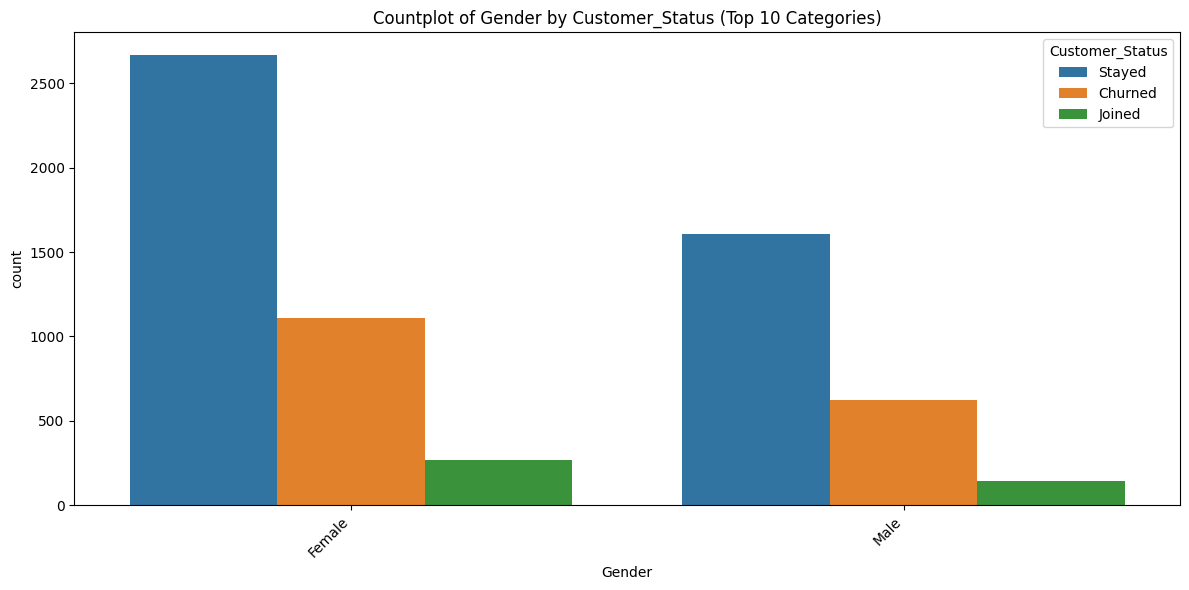

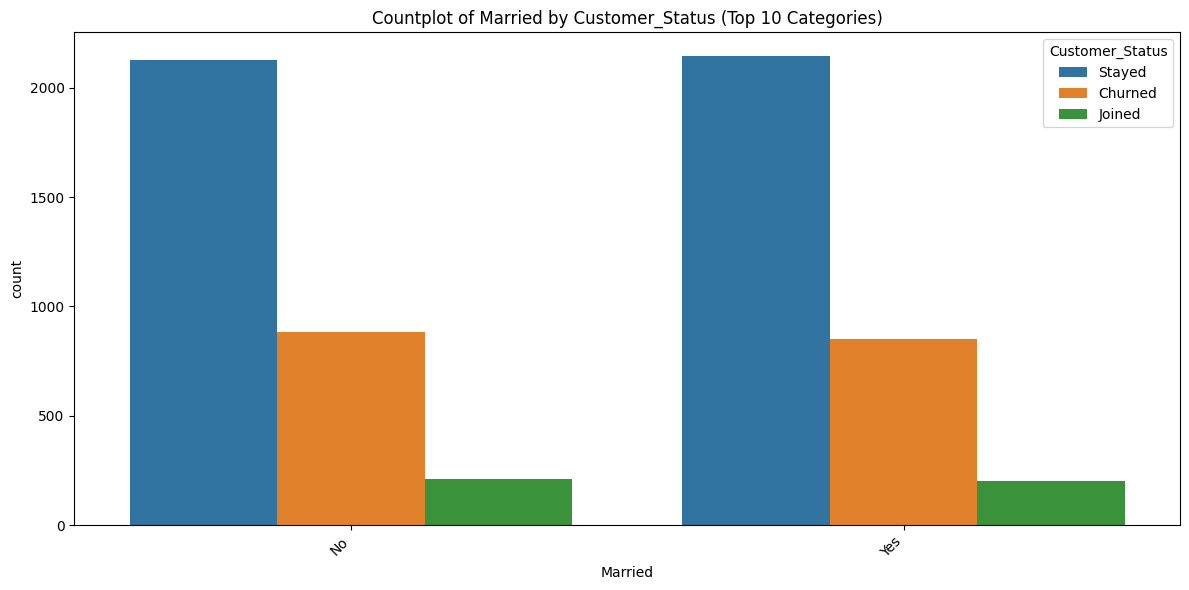

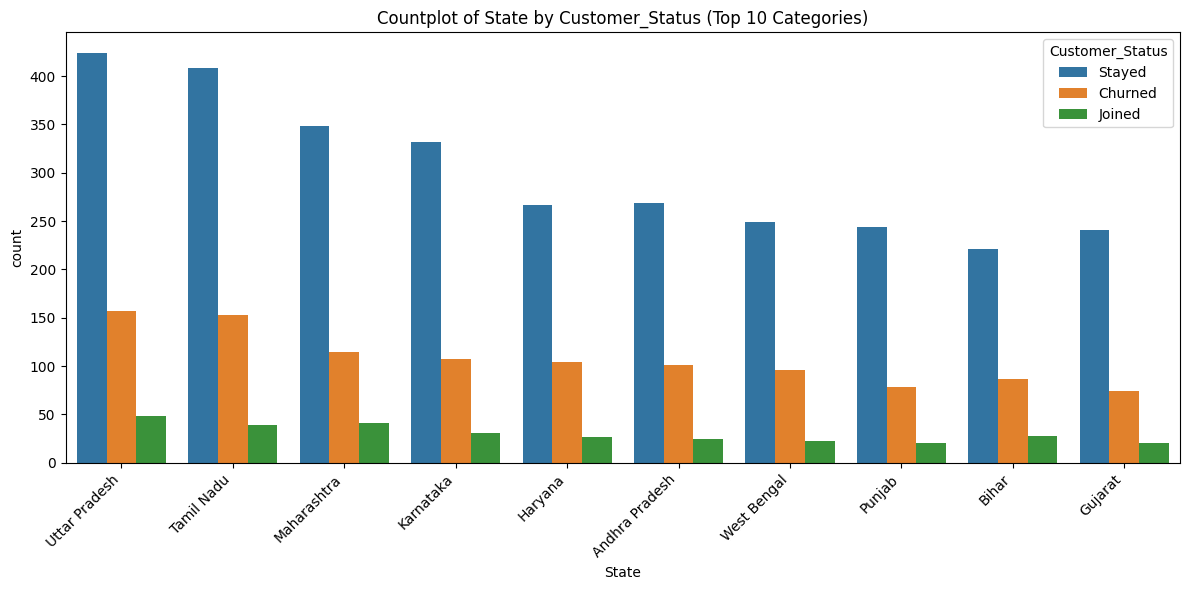

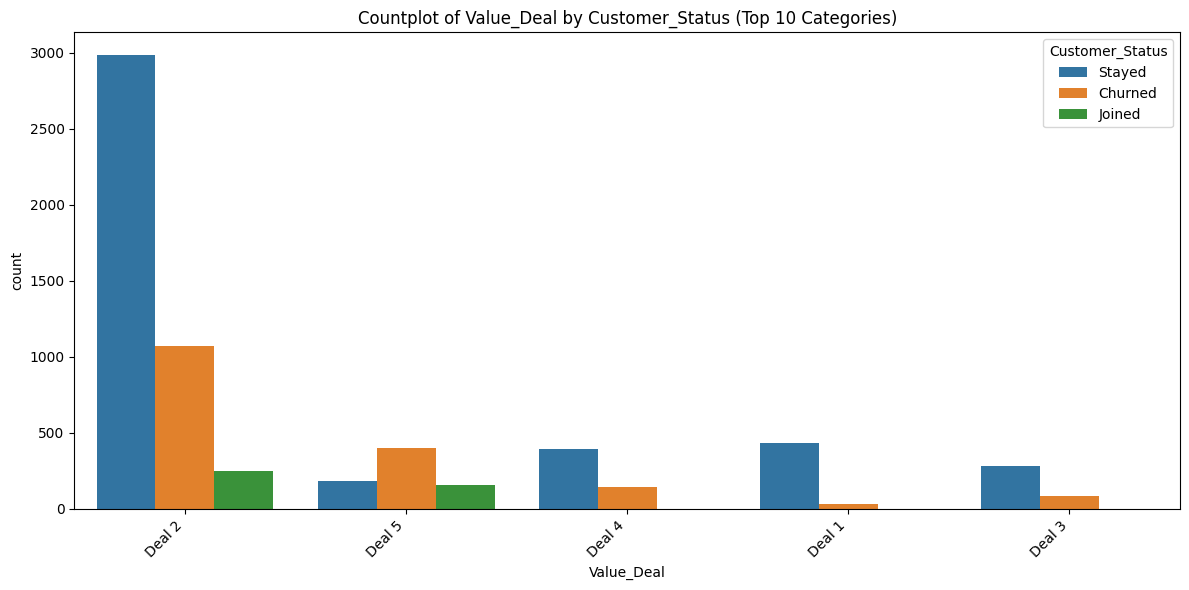

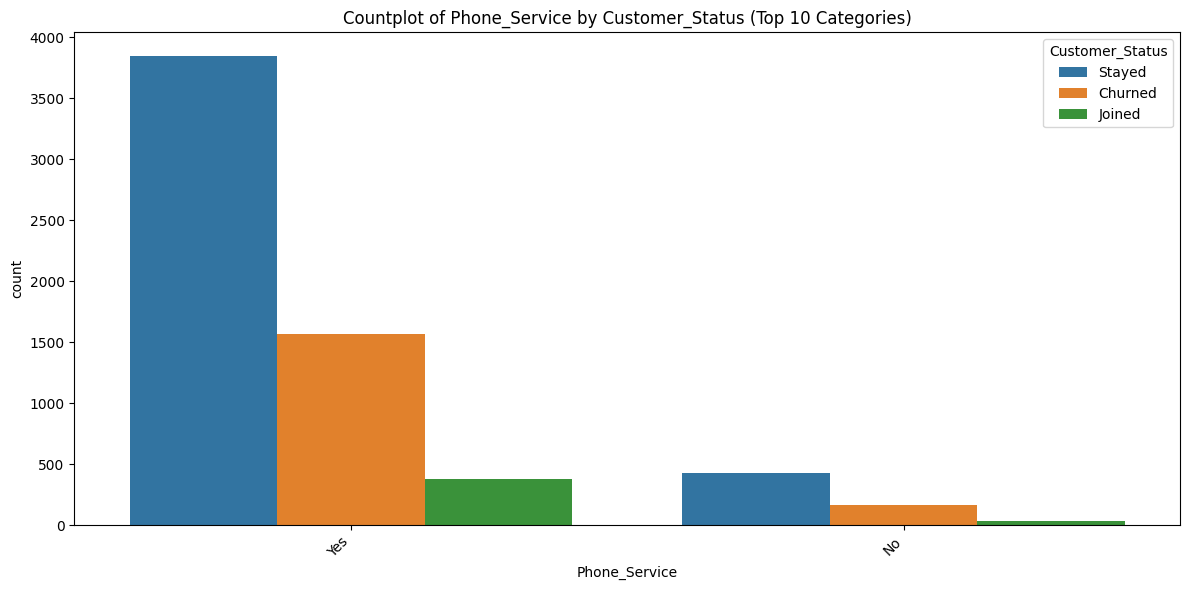

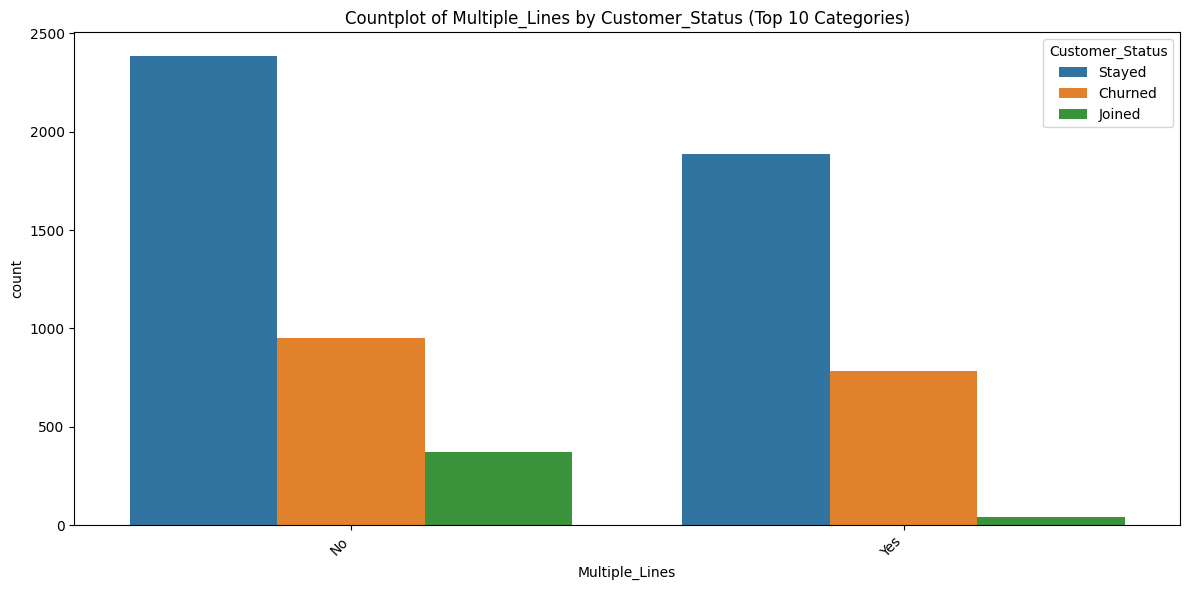

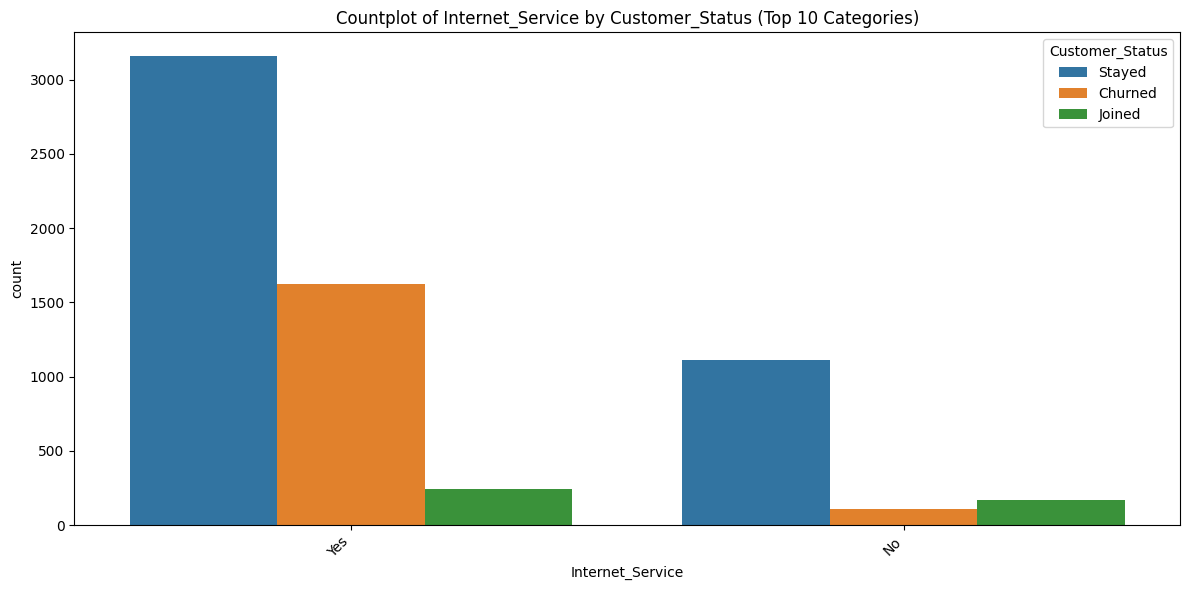

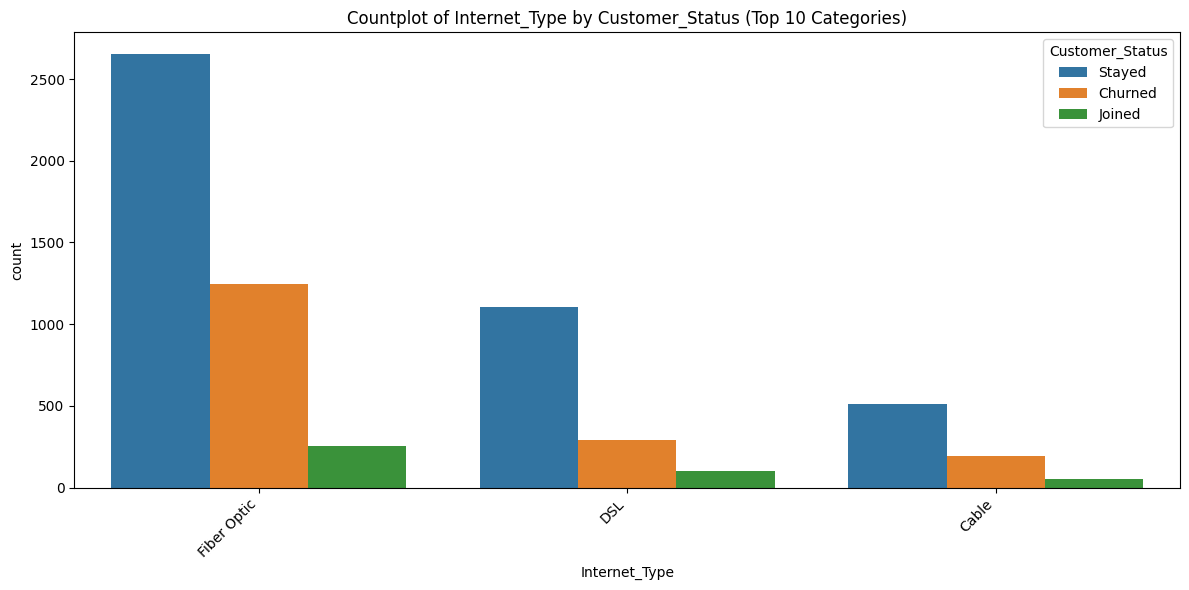

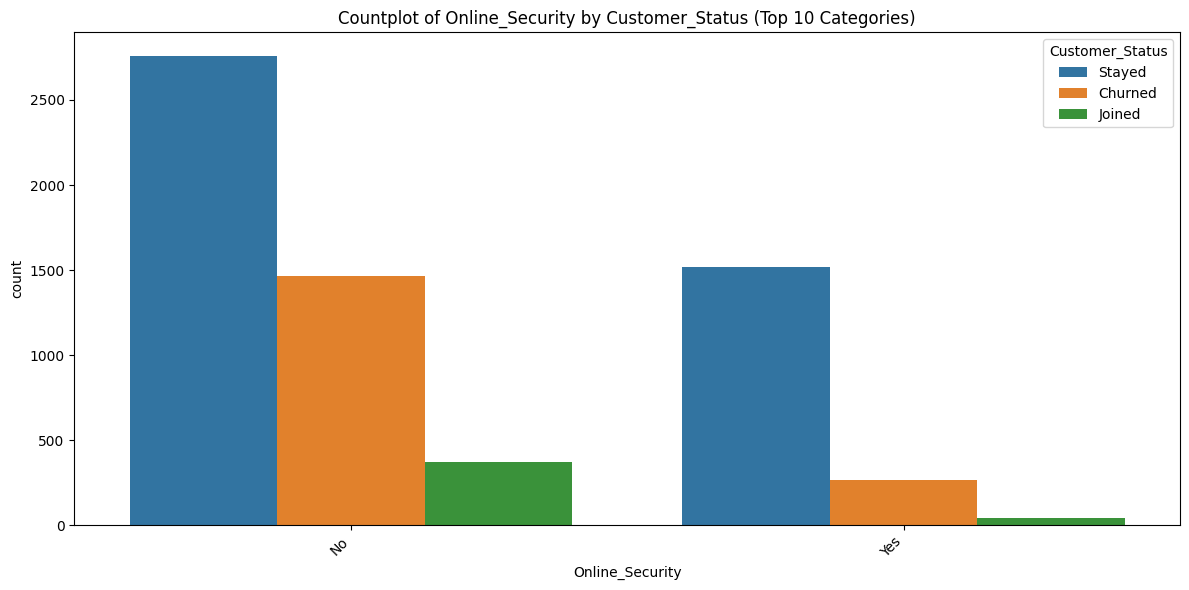

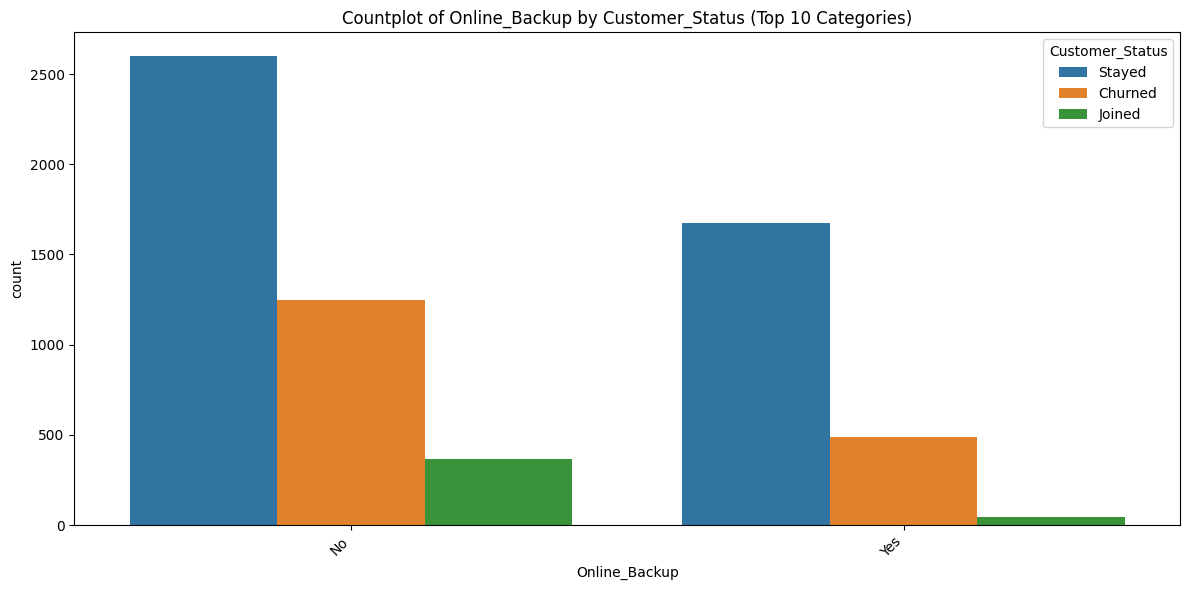

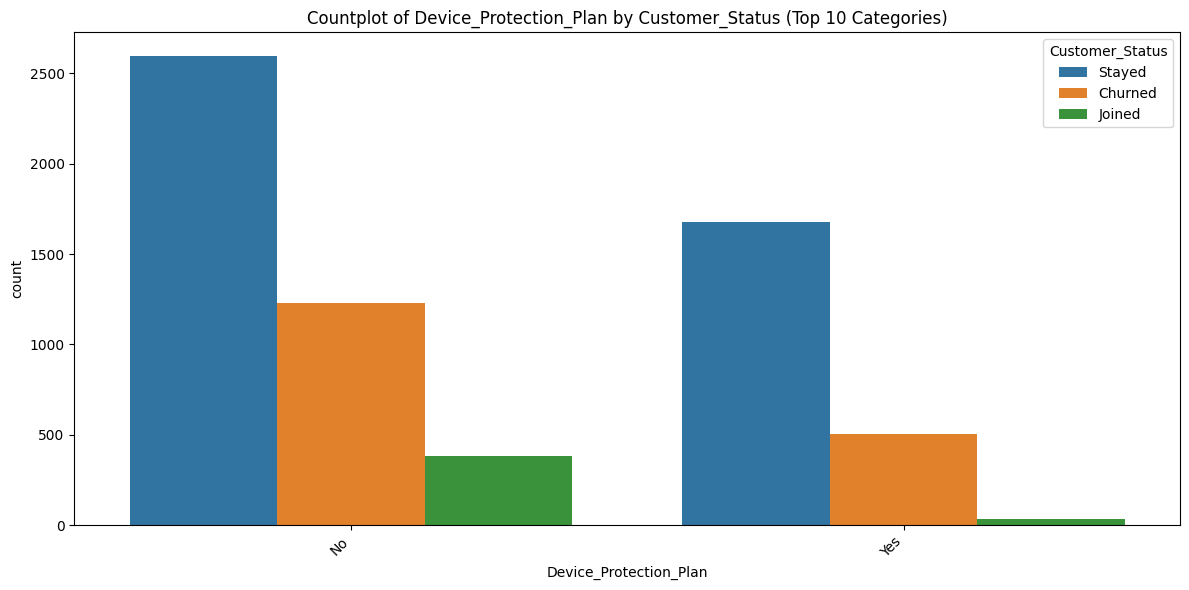

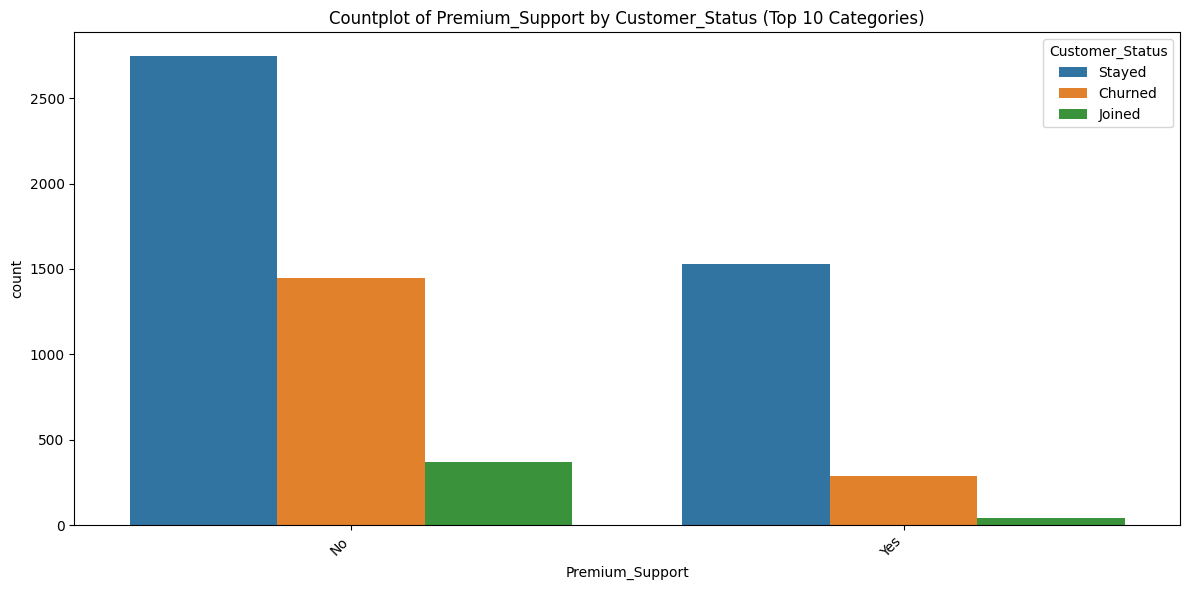

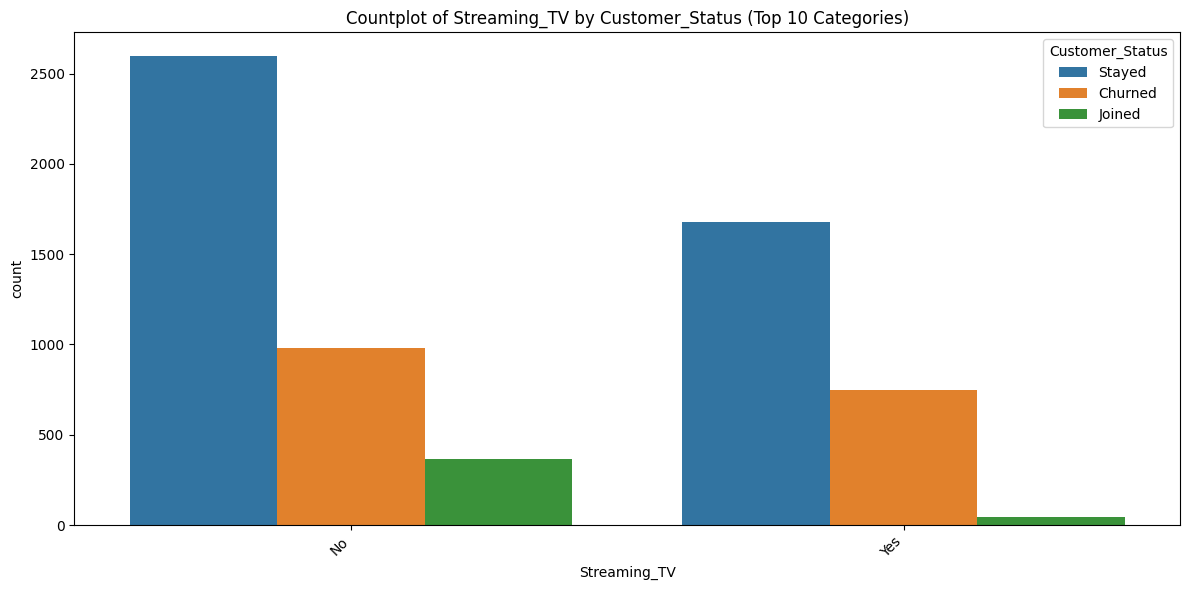

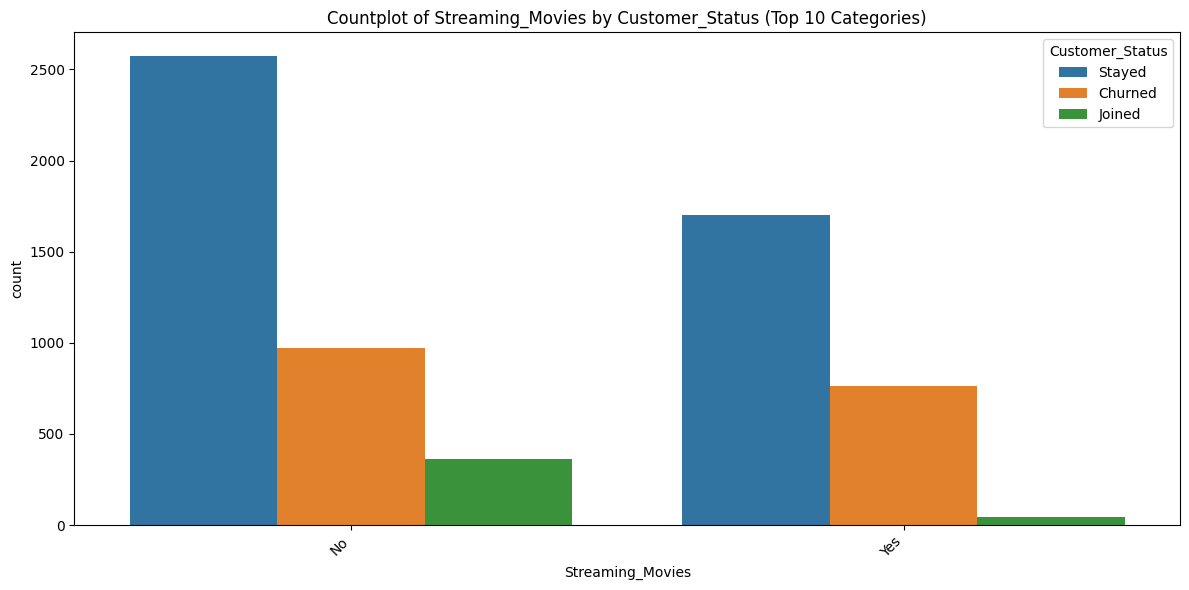

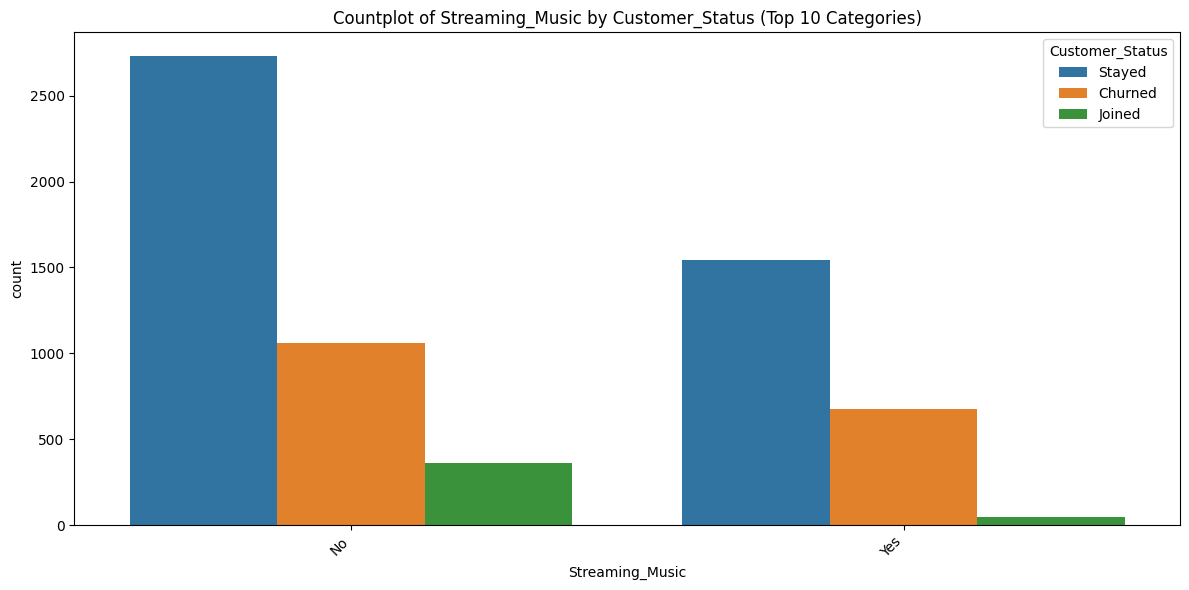

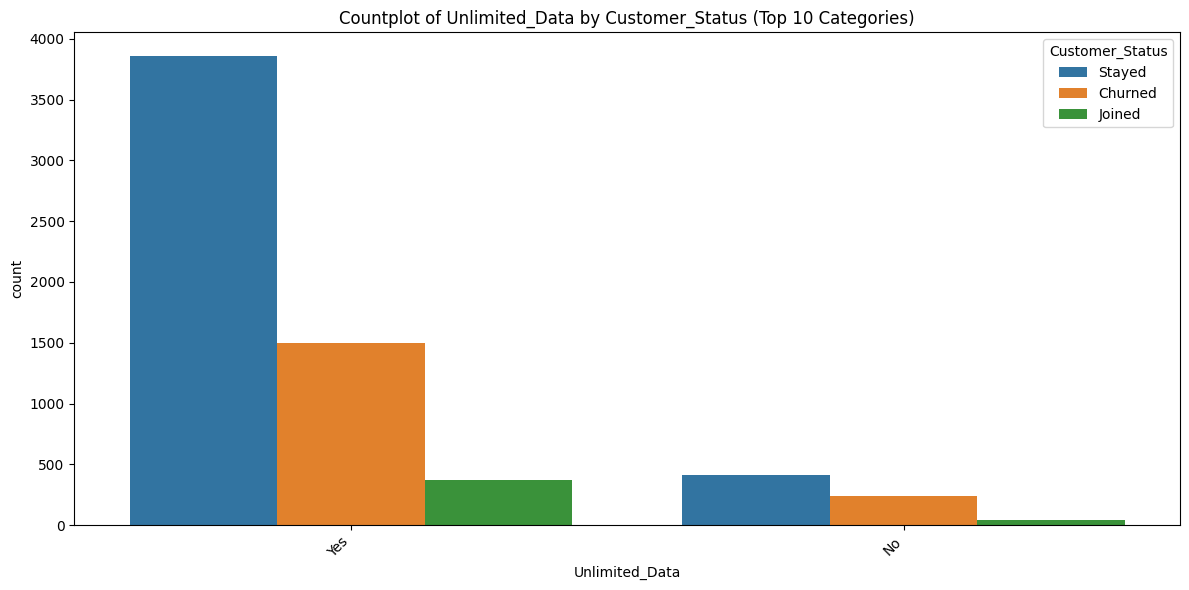

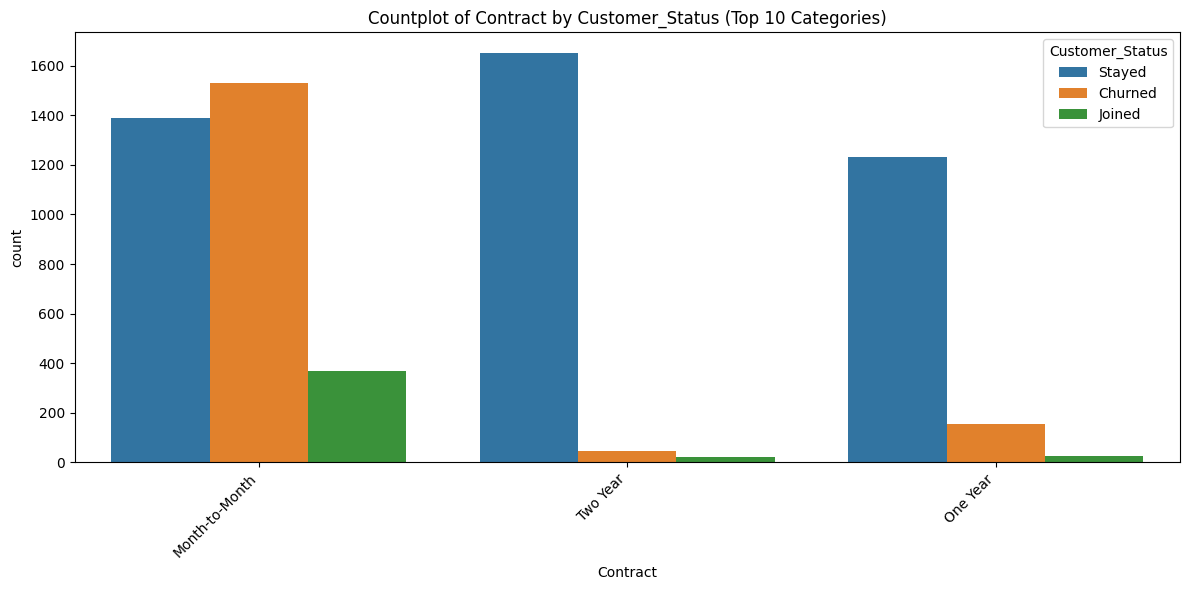

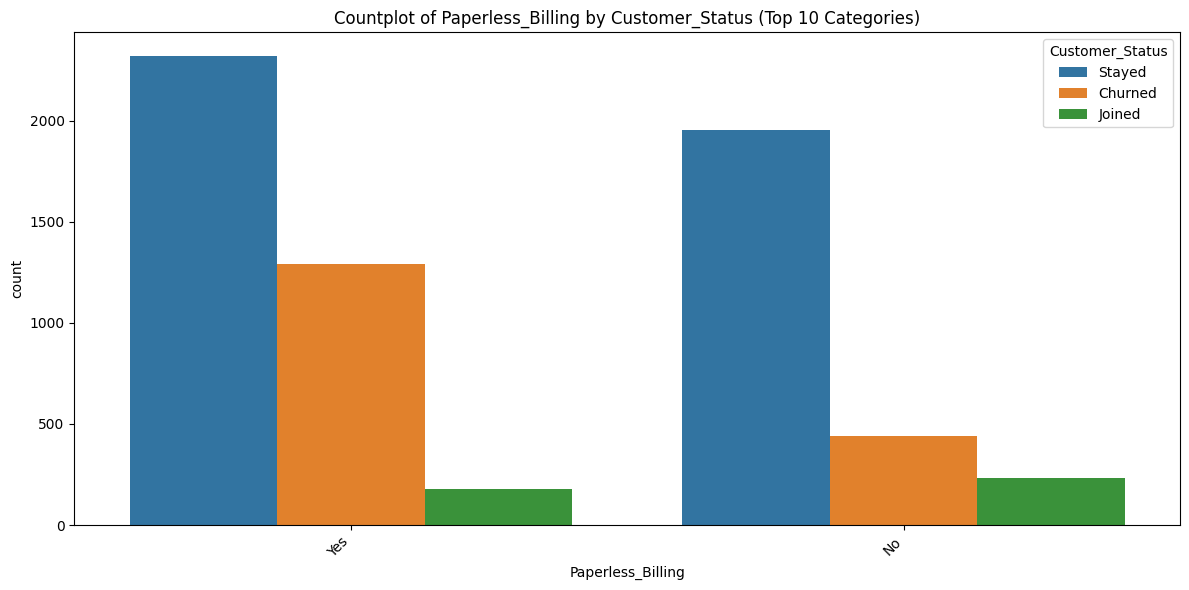

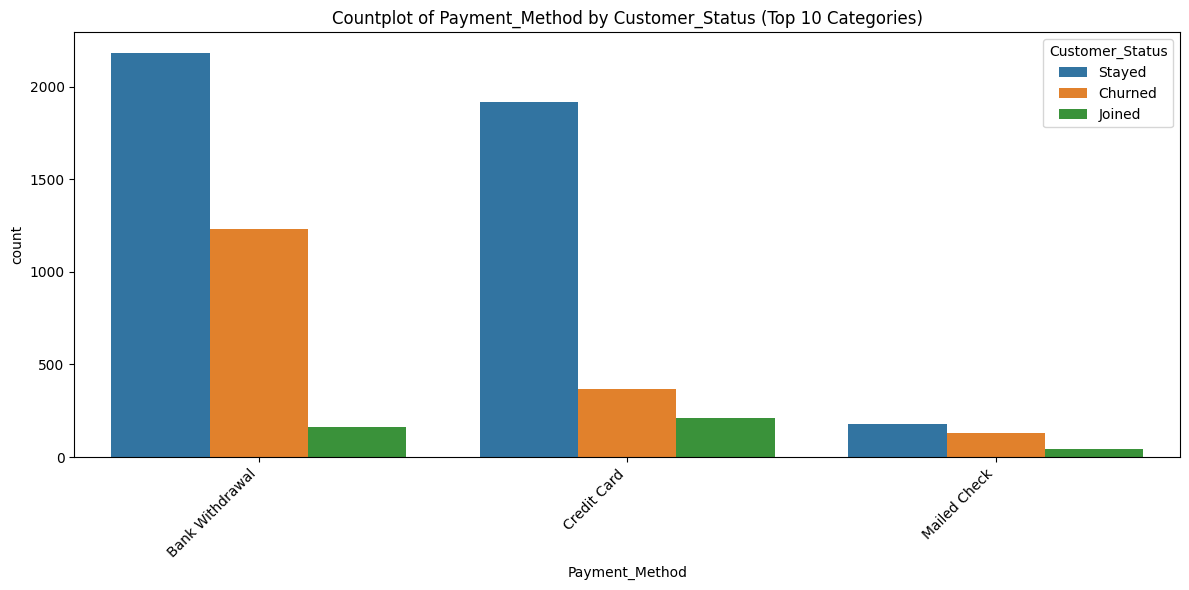

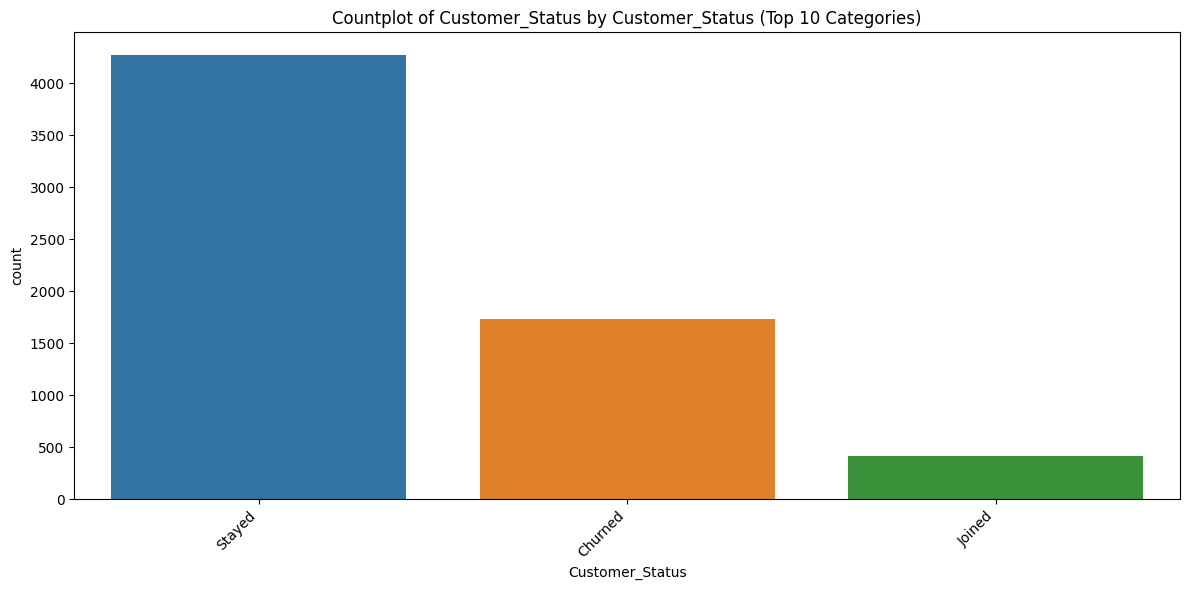

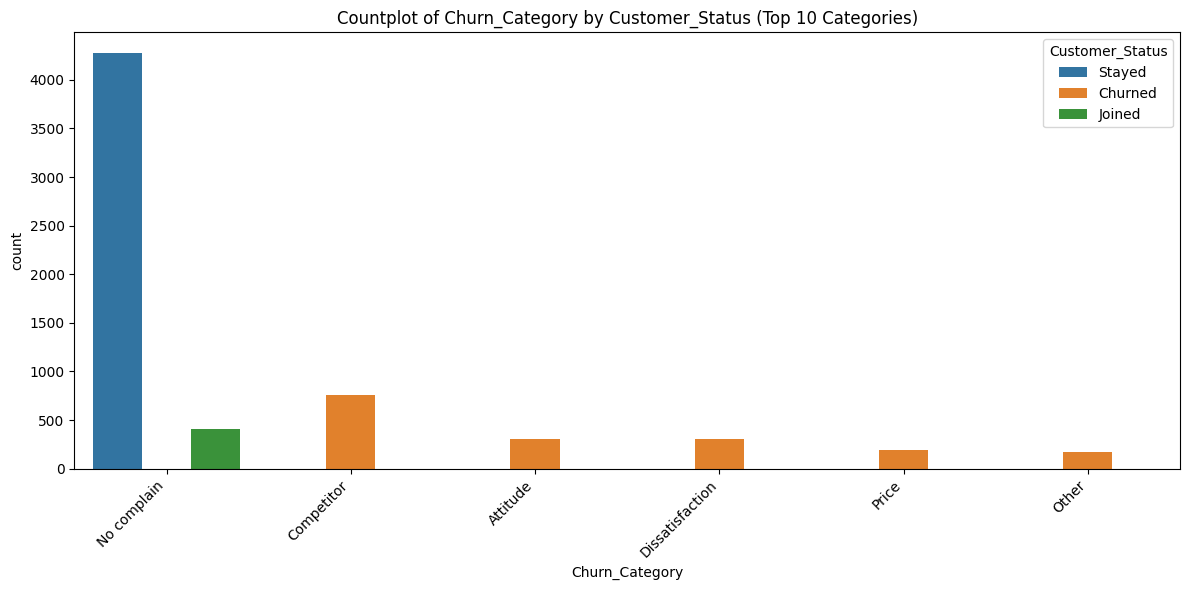

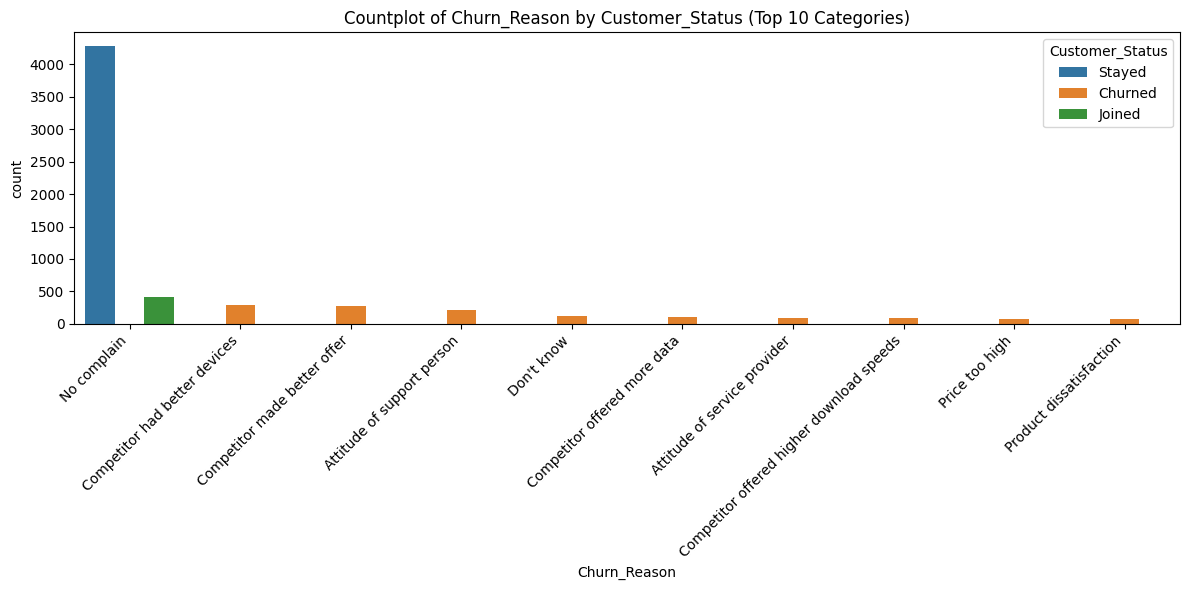

In [26]:
for col in cat_cols:
  # Get the top 10 categories for the current column, to use for ordering
  top_10_categories = df[col].value_counts().nlargest(10).index
  plt.figure(figsize=(12, 6)) # Adjust figure size for better readability
  sns.countplot(data=df, x=col, hue='Customer_Status', order=top_10_categories)
  plt.title(f'Countplot of {col} by Customer_Status (Top 10 Categories)')
  plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlap
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

In [27]:
for col in num_cols:
  print(col)
  print(df.groupby('Customer_Status')[col].agg(["mean","median","min","max","std"]))
  print("*"*50)



Age
                      mean  median  min  max        std
Customer_Status                                        
Churned          50.144919    50.0   18   84  17.693922
Joined           43.878345    43.0   18   85  14.797488
Stayed           46.132164    45.0   18   84  16.291567
**************************************************
Number_of_Referrals
                     mean  median  min  max       std
Customer_Status                                      
Churned          7.392610     7.0    0   15  4.548921
Joined           7.253041     7.0    0   15  4.611143
Stayed           7.458947     7.0    0   15  4.652188
**************************************************
Tenure_in_Months
                      mean  median  min  max        std
Customer_Status                                        
Churned          17.515589    17.0    1   36  10.662421
Joined           16.586375    15.0    1   36  10.314764
Stayed           17.345497    16.0    1   36  10.565489
***************************

1. high the monthly charge of customer ,high chance is that customer will churn
2. avg age of customer to be churn is around 50
3. churned customer pay extra more paying more for data charge



In [28]:
df.groupby('Customer_Status')['Age'].agg(['mean', 'median','min','max'])

,mean,median,min,max
Customer_Status,,,,
Churned,50.144919,50.0,18,84
Joined,43.878345,43.0,18,85
Stayed,46.132164,45.0,18,84


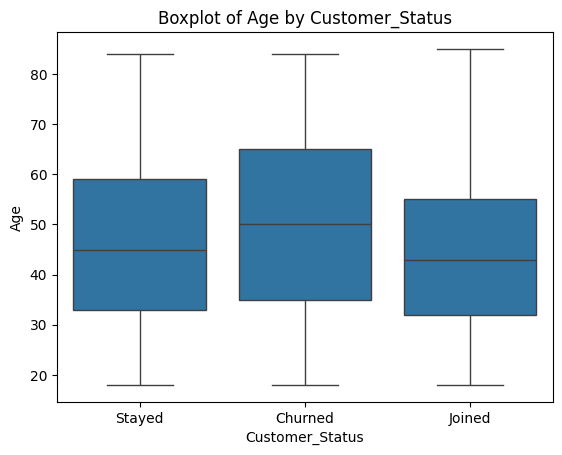

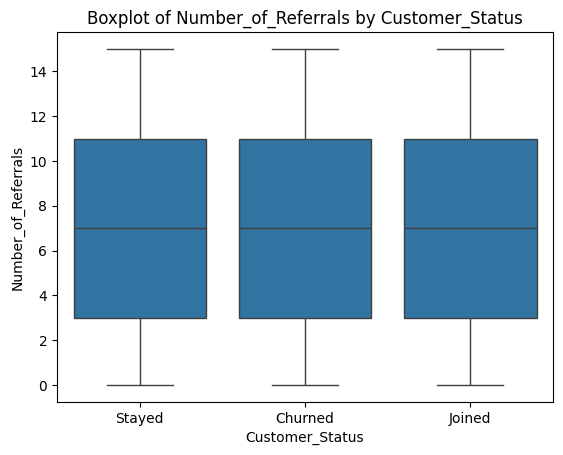

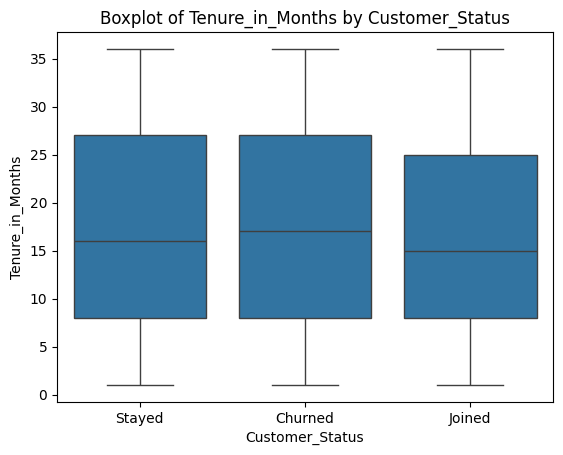

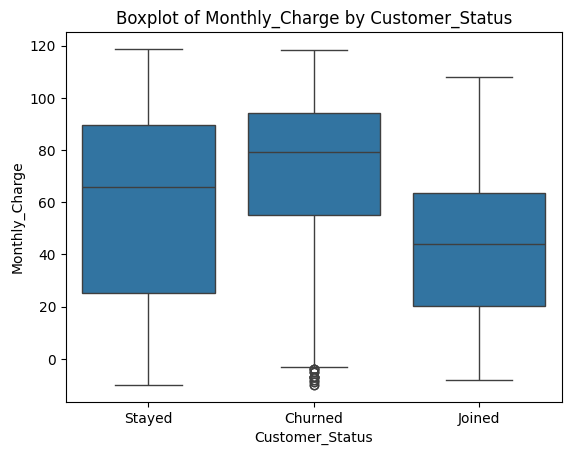

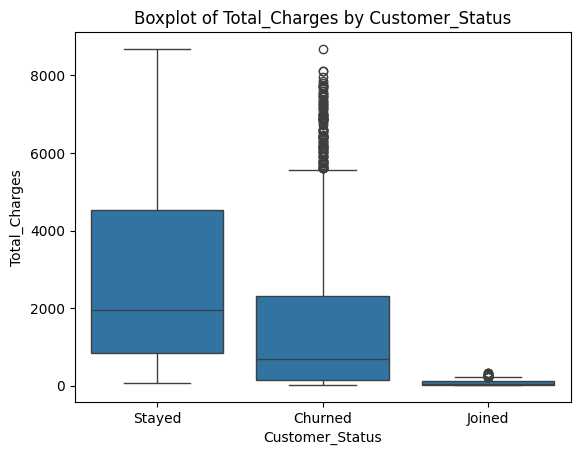

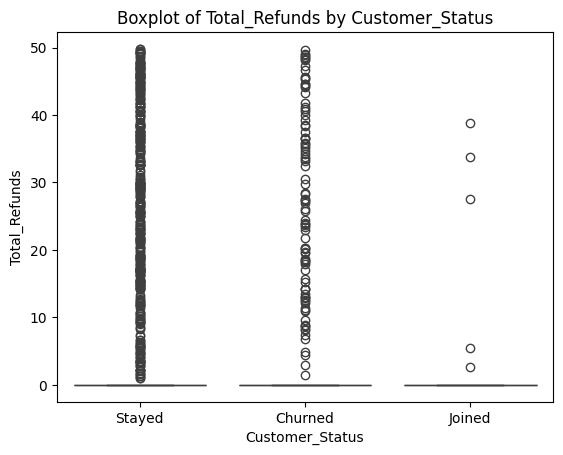

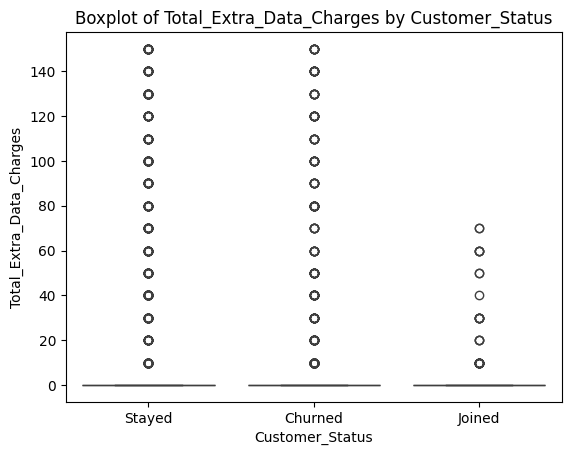

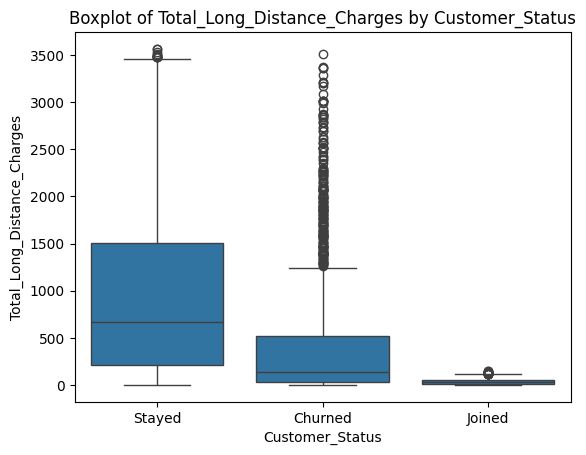

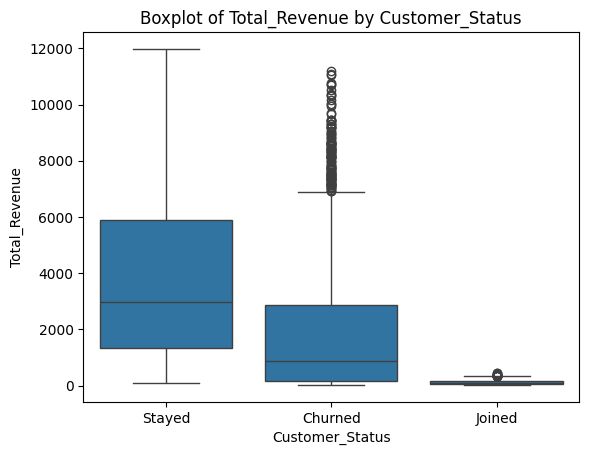

In [29]:
for col in num_cols:
  plt.figure()
  sns.boxplot(x='Customer_Status', y=col, data=df)
  plt.title(f'Boxplot of {col} by Customer_Status')
  plt.ylabel(col)

## Additional analysis: correlation, revenue impact, statistical validation, multivariate, churn reasons


### Correlation heatmap (numeric features)


In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()


### Revenue impact of churn (this was missing - Total_Revenue was never analyzed)


In [ ]:
revenue_by_status = df.groupby('Customer_Status')['Total_Revenue'].agg(['sum','mean','count'])
revenue_by_status['pct_of_total_revenue'] = revenue_by_status['sum'] / df['Total_Revenue'].sum() * 100
print(revenue_by_status)

total_revenue_lost = df.loc[df['Customer_Status']=='Churned', 'Total_Revenue'].sum()
print(f"\nTotal revenue lost to churned customers: {total_revenue_lost:,.2f}")
print(f"That is {total_revenue_lost/df['Total_Revenue'].sum()*100:.2f}% of total revenue in the dataset")


In [ ]:
# Average monthly charge & refunds for churned vs retained - do high payers churn more?
df.groupby('Customer_Status')[['Monthly_Charge','Total_Refunds','Total_Extra_Data_Charges']].mean()


### Statistical validation: chi-square test for each categorical variable vs Customer_Status
A low p-value (< 0.05) means the relationship is unlikely to be random noise - use this to decide which bivariate insights are actually worth reporting.


In [ ]:
from scipy.stats import chi2_contingency

chi2_results = []
for col in cat_cols:
    if col == 'Customer_Status':
        continue
    table = pd.crosstab(df[col], df['Customer_Status'])
    chi2, p, dof, exp = chi2_contingency(table)
    chi2_results.append({'column': col, 'chi2': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df


### Multivariate segmentation - combine two drivers at once
Bivariate analysis alone can hide interaction effects (e.g. contract type matters differently depending on internet type).


In [ ]:
# Churn rate by Contract + Internet_Type together, with segment size so small segments aren't over-trusted
segment = df.groupby(['Contract','Internet_Type']).agg(
    total_customers=('Customer_Status','count'),
    churn_rate_pct=('Customer_Status', lambda x: (x=='Churned').mean()*100)
).sort_values('churn_rate_pct', ascending=False)
segment


In [ ]:
# Churn rate by tenure bucket within each contract type
df['Tenure_Bucket'] = pd.cut(df['Tenure_in_Months'], bins=[0,6,12,24,36],
                              labels=['0-6','6-12','12-24','24-36'])

tenure_contract = df.groupby(['Contract','Tenure_Bucket']).agg(
    total_customers=('Customer_Status','count'),
    churn_rate_pct=('Customer_Status', lambda x: (x=='Churned').mean()*100)
)
tenure_contract


### Root cause: Churn_Reason by segment
Now that we know *who* churns most, look at *why* within those segments.


In [ ]:
# Churn reasons among month-to-month churners specifically (swap the filter for any segment you want to inspect)
churned = df[df['Customer_Status'] == 'Churned']

reason_by_contract = pd.crosstab(churned['Contract'], churned['Churn_Reason'], normalize='index') * 100
reason_by_contract


In [ ]:
# Top overall churn reasons, ranked, with count so rare reasons don't look bigger than they are
churned['Churn_Reason'].value_counts().to_frame('count').assign(
    pct=lambda d: d['count'] / d['count'].sum() * 100
)


### Summary of findings (fill in the actual numbers once you run the cells above)

1. Revenue lost to churn: ~X% of total revenue in the dataset — the single biggest number to lead with.
2. Highest-risk segment: [Contract] + [Internet_Type] combination churns at X% vs Y% baseline.
3. Tenure risk window: churn is concentrated in the first X months, especially on month-to-month contracts.
4. Statistically significant drivers (p < 0.05 from chi-square): list the top few columns from `chi2_df`.
5. Leading churn reasons: [reason 1] and [reason 2] account for X% of all churn.

**Recommendation:** e.g. target month-to-month customers within their first 6 months with a retention offer,
since this segment accounts for the largest share of lost revenue.
